# Financial Inclusion in Africa — Starter Notebook
### Miva Open University Hackathon

**Objective:** Build a machine learning model to predict which individuals are most likely to have or use a bank account.

**Target variable:** `bank_account` — `1` = Has a bank account, `0` = Does not

**Evaluation metric:** Accuracy

---

### Notebook Roadmap
1. Import Libraries
2. Load the Data
3. Explore the Data (EDA)
4. Preprocess the Data
5. Train a Model
6. Evaluate the Model
7. Generate Submission File

## Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Charts appear inline inside the notebook
%matplotlib inline
sns.set(style='whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


# load files

In [25]:
# pd.read_csv() reads a CSV file into a DataFrame (a table in Python)
train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')
sample_submission = pd.read_csv('SampleSubmission.csv')

# .shape returns (number of rows, number of columns)
print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')

Train shape: (23524, 13)
Test shape:  (10086, 12)


In [26]:
# .head() shows the first 5 rows — great for a quick look at the data
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [27]:
# Notice the test data has NO 'bank_account' column!
# That is exactly what we need to predict.
test.head()

,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent


# Exploratory Data Analysis (EDA)

In [28]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   country                 23524 non-null  str  
 1   year                    23524 non-null  int64
 2   uniqueid                23524 non-null  str  
 3   bank_account            23524 non-null  str  
 4   location_type           23524 non-null  str  
 5   cellphone_access        23524 non-null  str  
 6   household_size          23524 non-null  int64
 7   age_of_respondent       23524 non-null  int64
 8   gender_of_respondent    23524 non-null  str  
 9   relationship_with_head  23524 non-null  str  
 10  marital_status          23524 non-null  str  
 11  education_level         23524 non-null  str  
 12  job_type                23524 non-null  str  
dtypes: int64(3), str(10)
memory usage: 2.3 MB


In [29]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
year,23524.0,2016.975939,0.847371,2016.0,2016.0,2017.0,2018.0,2018.0
household_size,23524.0,3.797483,2.227613,1.0,2.0,3.0,5.0,21.0
age_of_respondent,23524.0,38.805220,16.520569,16.0,26.0,35.0,49.0,100.0


In [30]:
# Check for missing values — columns with many nulls need special handling
print('Missing values per column:')
print(train.isnull().sum())

Missing values per column:
country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64


In [31]:
# How balanced is our target variable?
# If one class is much larger, we have a 'class imbalance' problem — important to know!
print('Bank account distribution:')
print(train['bank_account'].value_counts())
print()
print('As percentages:')
print(train['bank_account'].value_counts(normalize=True) * 100)

Bank account distribution:
bank_account
No     20212
Yes     3312
Name: count, dtype: int64

As percentages:
bank_account
No     85.920762
Yes    14.079238
Name: proportion, dtype: float64


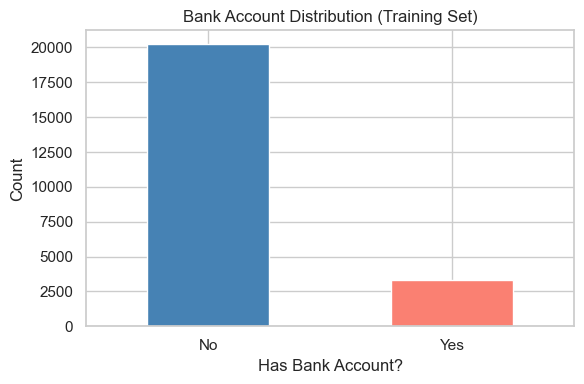

In [32]:
# Visualise class balance
plt.figure(figsize=(6, 4))
train['bank_account'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Bank Account Distribution (Training Set)')
plt.xlabel('Has Bank Account?')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

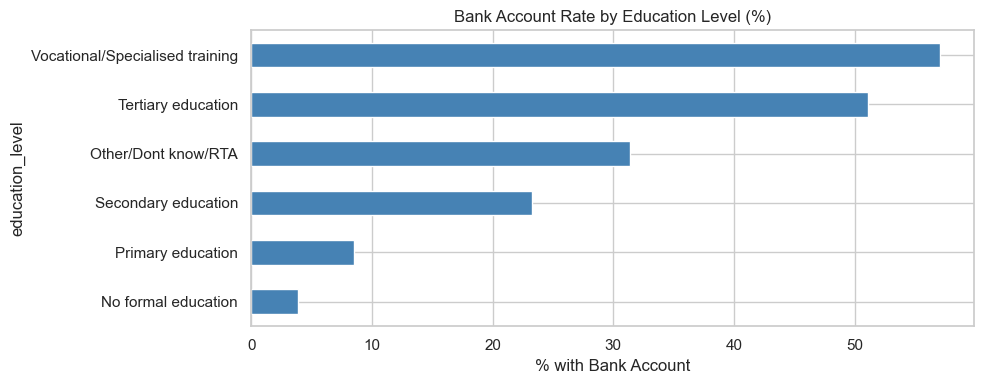

In [33]:
# Does education level affect bank account ownership?
# We calculate the percentage with a bank account for each education level
edu_rate = train.groupby('education_level')['bank_account'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values()

plt.figure(figsize=(10, 4))
edu_rate.plot(kind='barh', color='steelblue')
plt.title('Bank Account Rate by Education Level (%)')
plt.xlabel('% with Bank Account')
plt.tight_layout()
plt.show()
# Question: Does higher education link to higher bank account ownership?

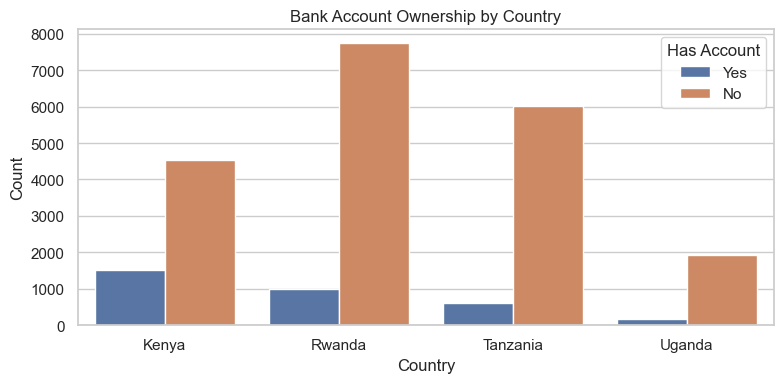

In [34]:
# Bank account ownership by country
plt.figure(figsize=(8, 4))
sns.countplot(data=train, x='country', hue='bank_account')
plt.title('Bank Account Ownership by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Has Account')
plt.tight_layout()
plt.show()

## little findings

the dataset is imbalanced and if we are going to get a better model performance we need to take care of this issue
before trying to predict anything




In [35]:
# drop unique identifier columns that won't help the model
train.drop(['uniqueid'], axis=1, inplace=True)
test.drop(['uniqueid'], axis=1, inplace=True)


In [36]:
# train/validation split
X = train.drop('bank_account', axis=1)  # Features
y = train['bank_account']  # Target variable    
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')


Training set: 16466 samples
Validation set: 7058 samples


## Treating imbalance in the data set

In [37]:
# 1. Automatically find categorical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# 2. Initialize OrdinalEncoder (Safe for unseen categories in the test set)
# Unseen categories will be encoded as -1 instead of crashing
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 3. Encode X_train and X_val safely
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_val[categorical_cols] = encoder.transform(X_val[categorical_cols])

# 4. ASSEMBLE PIPELINE: SMOTE -> Model (Since encoding is already done)
pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])



C:\Users\USER\AppData\Local\Temp\ipykernel_26340\208758445.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns


### checking if the imbalamce situation was sorted 

In [38]:

# Assuming you apply SMOTE to your training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check the new distribution! Both classes should now have the exact same count
print("After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


After SMOTE:
bank_account
No     14139
Yes    14139
Name: count, dtype: int64


### checking samples of the encoded data set

In [39]:
# 3. Create copies to avoid changing the original DataFrames and prevent warnings
X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()

# 4. Fit the encoder on the training data and transform both train and validation sets
X_train_encoded[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_val_encoded[categorical_cols] = encoder.transform(X_val[categorical_cols])


print("Sample of the encoded training data (X_train_encoded):")
X_train_encoded.head()

Sample of the encoded training data (X_train_encoded):


,country,year,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
19929,2.0,2017,1.0,1.0,2,25,0.0,5.0,3.0,2.0,8.0
13449,1.0,2016,0.0,1.0,4,46,0.0,1.0,4.0,3.0,1.0
5449,0.0,2018,1.0,1.0,4,39,1.0,1.0,2.0,3.0,9.0
6956,1.0,2016,0.0,1.0,5,61,0.0,1.0,4.0,0.0,1.0
2737,0.0,2018,0.0,0.0,5,24,0.0,5.0,2.0,2.0,1.0


In [40]:
# Train the pipeline on your encoded training data

pipeline.fit(X_train_encoded, y_train)


,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [41]:
# Predict the target variable for the validation set
y_pred = pipeline.predict(X_val_encoded)


In [42]:

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Confusion Matrix:
[[5586  487]
 [ 552  433]]

Classification Report:
              precision    recall  f1-score   support

          No       0.91      0.92      0.91      6073
         Yes       0.47      0.44      0.45       985

    accuracy                           0.85      7058
   macro avg       0.69      0.68      0.68      7058
weighted avg       0.85      0.85      0.85      7058



C:\Users\USER\AppData\Local\Temp\ipykernel_26340\228005341.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


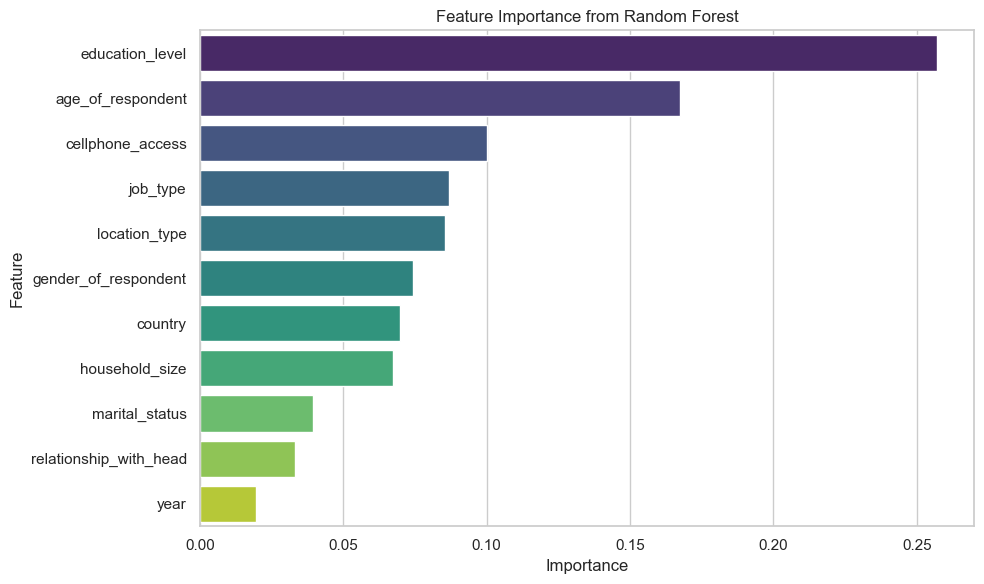

In [43]:
# Feature Importance — which inputs did the model rely on most?
# Higher bar = more influence on the model's decisions
feature_importances = pipeline.named_steps['model'].feature_importances_
features = X_train_encoded.columns  
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance from Random Forest')  
plt.tight_layout()
plt.show()  


In [44]:
# Encode categorical columns in the test set using the same approach as training
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Re-fit encoder on the original training features (X) to ensure consistent categories
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder.fit(X[categorical_cols])

# Apply encoding to test set
test_encoded = test.copy()
test_encoded[categorical_cols] = encoder.transform(test_encoded[categorical_cols])

# quick check
test_encoded.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_26340\1542311848.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns


,country,year,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,0.0,2018,1.0,1.0,3,30,1.0,1.0,2.0,3.0,2.0
1,0.0,2018,1.0,1.0,7,51,1.0,1.0,2.0,5.0,3.0
2,0.0,2018,0.0,0.0,3,77,0.0,4.0,2.0,0.0,8.0
3,0.0,2018,0.0,0.0,6,39,0.0,1.0,2.0,2.0,8.0
4,0.0,2018,1.0,0.0,3,16,1.0,0.0,3.0,3.0,8.0


In [46]:
# make predictions on the test set using the trained pipeline
test_predictions = pipeline.predict(test_encoded)   


In [47]:
test_predictions[:10]  # Show the first 10 predictions

array(['Yes', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes'],
      dtype=object)

In [48]:
# print the summary of predictions to see how many 'Yes' vs 'No' we have
print("Test set prediction distribution:")
print(pd.Series(test_predictions).value_counts())


Test set prediction distribution:
No     8835
Yes    1251
Name: count, dtype: int64


In [ ]:
# Build the unique_id column in the required format
# We use the original (non-encoded) test data for this
test_copy = test.copy()
if 'uniqueid' in test_copy.columns:
    test_copy['unique_id'] = test_copy['uniqueid'].astype(str) + ' x ' + test_copy['country'].astype(str)
else:
    test_copy = test_copy.reset_index(drop=True)
    test_copy['unique_id'] = 'uniqueid_' + (test_copy.index + 1).astype(str) + ' x ' + test_copy['country'].astype(str)

# Assemble the submission DataFrame
submission = pd.DataFrame({
    'unique_id': test_copy['unique_id'].values,
    'bank_account': test_predictions
})

print('Preview of submission:')
submission.head(10)

KeyError: 'uniqueid'